# VAR Family Investigation — Market Data

We are opening the case with six daily market series: Gold, Silver, Oil, the S&P 500, Bitcoin, and the U.S. Dollar Index (DXY). First fetch the last two years of observations; then inspect and prepare the data for VAR analysis.

The fetcher saves a tidy CSV beside this notebook in `data/`. Yahoo Finance symbols used: GC=F, SI=F, CL=F, ^GSPC, BTC-USD, and DX-Y.NYB. Prices and volumes are market-specific; compare returns rather than raw price levels when appropriate.

## 1. Fetch Data

In [11]:
from pathlib import Path
import fetch_market_data

reset_data = False
csv_path = Path("data/market_data_2y_daily.csv")

if reset_data:
    csv_path = fetch_market_data.fetch_all()
else:
    print("Using saved data:", csv_path)

Using saved data: data/market_data_2y_daily.csv


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from plot import get_market_chart
from utils import save_plot

data = pd.read_csv(csv_path, parse_dates=["Date"])
data.head()

,Date,Market,Ticker,Open,High,Low,Close,AdjClose,Volume
0,2021-09-17,Gold,GC=F,1754.599976,1767.800049,1747.099976,1751.400024,1751.400024,183254.0
1,2021-09-20,Gold,GC=F,1754.199951,1768.400024,1742.300049,1763.800049,1763.800049,152451.0
2,2021-09-21,Gold,GC=F,1765.500000,1782.800049,1758.300049,1778.199951,1778.199951,141622.0
3,2021-09-22,Gold,GC=F,1775.000000,1788.400024,1764.599976,1778.800049,1778.800049,172348.0
4,2021-09-23,Gold,GC=F,1769.199951,1777.099976,1737.500000,1749.800049,1749.800049,225456.0


In [18]:
custom_palleter = {'Oil':'k', 'USD':'tab:blue', 'Gold':'Gold', 'Silver':'Silver', 'S&P':'tab:green', 'BTC':'orange'}

#### Slide 1

/Users/bloodphilic/Desktop/dev/AlgoStalk/course/TimeSeries/VAR/detective_slides/assets/gold-price-opening-slide.png


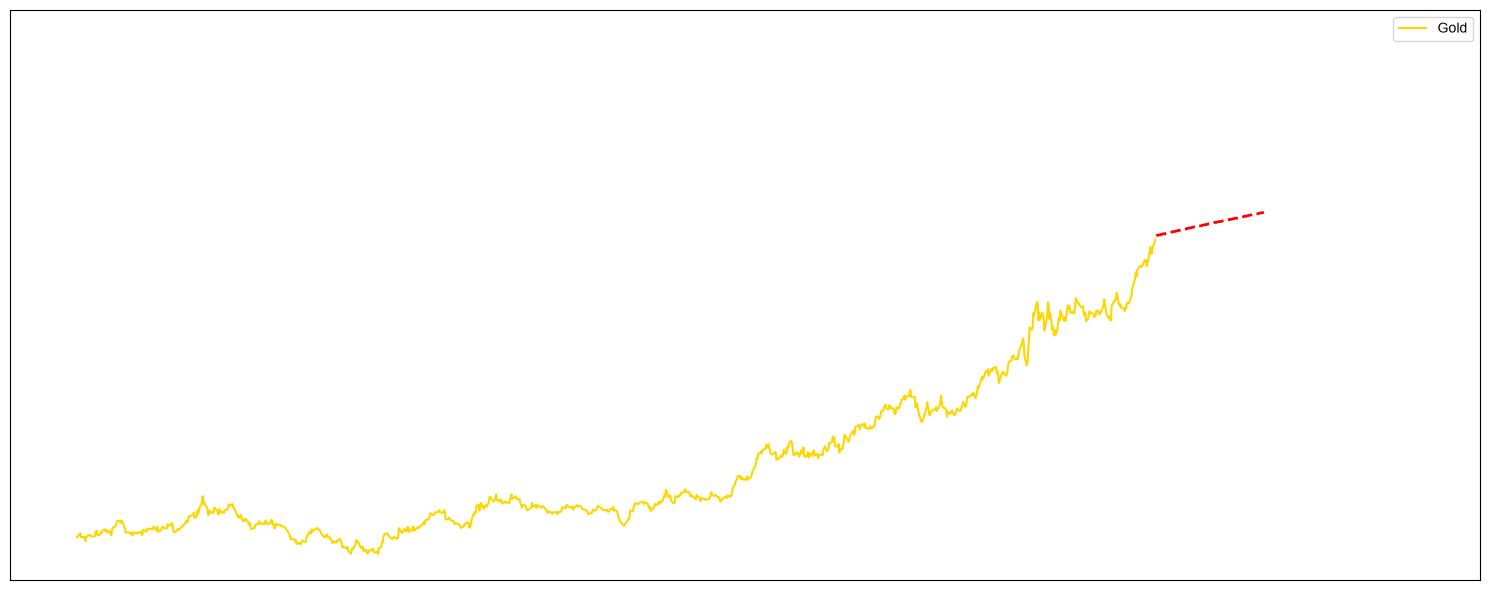

In [ ]:
import numpy as np

plt.rcParams["font.family"] = "Arial"

gold = data[data["Market"] == "Gold"].dropna(subset=["Close"]).sort_values("Date")
cutoff = pd.Timestamp("2025-10-01")

gold_before = gold[gold["Date"] <= cutoff]
gold_after = gold[gold["Date"] > cutoff]

ax = get_market_chart(gold_before, "Date", "Close", label="Gold", color="gold")
get_market_chart(gold[gold["Date"] >= cutoff], "Date", "Close", label="_nolegend_", color="white", ax=ax)

# Fit a straight trend to all Gold observations up to the cutoff.
x = np.arange(len(gold_before))
slope, intercept = np.polyfit(x, gold_before["Close"], 1)

# Extend it 20 observations beyond the cutoff.
future_dates = gold_after["Date"].head(100)
trend_dates = pd.concat([pd.Series([cutoff]), future_dates], ignore_index=True)
trend_x = np.arange(len(future_dates) + 1)
cutoff_price = gold_before["Close"].iloc[-1]
trend_values = cutoff_price + slope * trend_x
ax.plot(trend_dates, trend_values, color="red", linestyle="--", linewidth=2)
ax.legend()
ax.figure.tight_layout()

plt.show()


Narration

The case looked simple.

You built the model.

You checked the rules.

You ran the forecast.

You looked confident.

*“The model has spoken,”* you said.

But then...

#### Slide 2

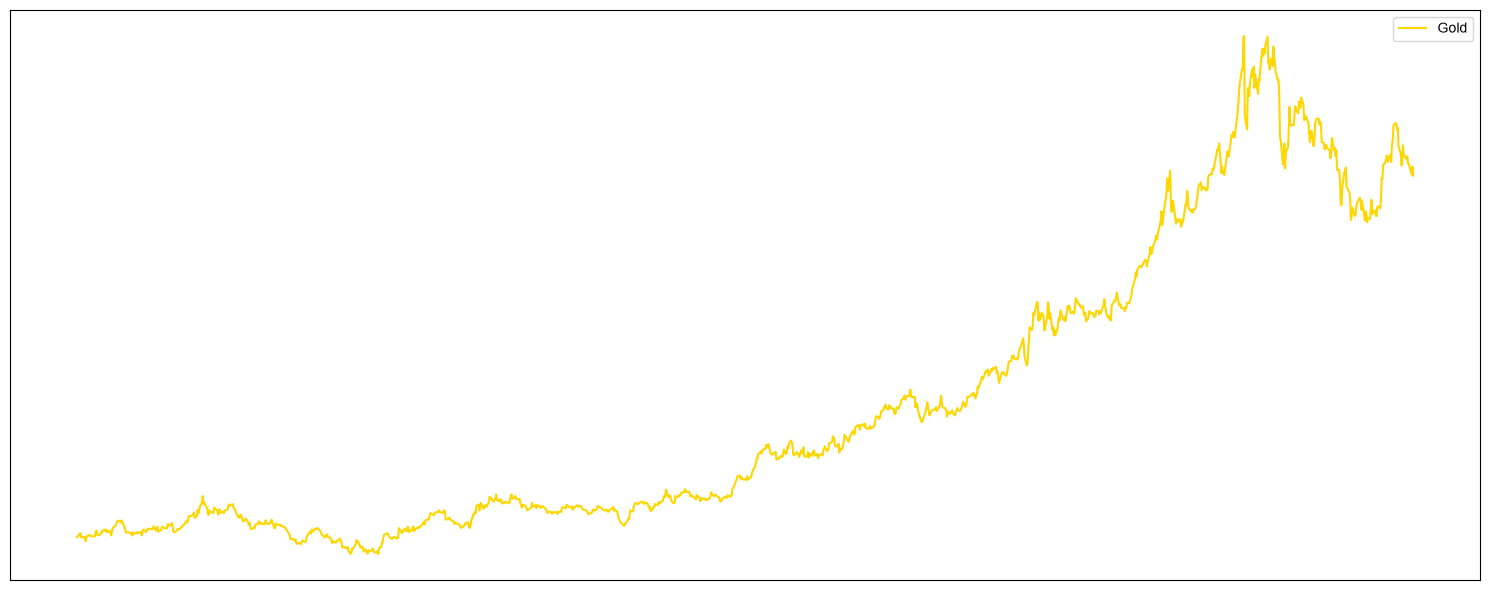

In [17]:
ax = get_market_chart(gold, "Date", "Close", label="Gold", color="gold")
ax.legend()
ax.figure.tight_layout()
plt.show()

#### Slide 3 — The markets move together


In [ ]:
markets = ["Gold", "Silver", "Oil", "SP500", "BTC", "DXY"]

market_prices = data.pivot(index="Date", columns="Market", values="Close").reset_index()

ax = get_market_chart(
    market_prices,
    "Date",
    markets,
    normalize="zscore",
    hide_ticks=False,
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Standardized close price (z-score)")
ax.set_title("Six markets, standardized for comparison")
ax.legend(ncol=3)
ax.figure.tight_layout()
save_plot(ax.figure, "slide-3-normalized-markets.png")
plt.show()
